# Local 384-Well Plate HTS Normalization Pipeline
This notebook loads an assay file directly from your computer, extracts control baseline values, and normalizes sample wells into **Percent of Control (POC)**.

### Mathematical Formulation
$$POC_i = \left( \frac{\text{Value}_i - \mu_{\text{Low}}}{\mu_{\text{High}} - \mu_{\text{Low}}} \right) \times 100$$


In [43]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", 50)
plt.rcParams["figure.facecolor"] = "white"
%matplotlib inline

# ---------------- CONFIG ----------------
DATA_DIR = r"C:\Users\sbrown\Documents\2026\08282020_GPR52_glosensor_S1P1_CYM_Lib\Data\ratios"
PLATE_MAP_PATH = os.path.join(DATA_DIR, "plate_map.csv")   # update if filename differs
DATA_FILE_PATTERN = "*.csv"

N_ROWS, N_COLS = 16, 24

# Well type labels as they appear in your plate map (matched case-insensitively)
LOW_CTRL_LABEL  = "LC"
HIGH_CTRL_LABEL = "HC"
SAMPLE_LABEL    = "Cmpnd"
FORSK_LABEL     = "Forsk"     # reference/control compound, reported but not used for normalization

# % of Control formula:
#   "vs_LC" : POC = 100 * signal / mean(LC)   (LC = 100% baseline)
#   "vs_HC" : POC = 100 * signal / mean(HC)   (HC = 100% max effect)
#   "window": POC = 100 * (signal - mean(LC)) / (mean(HC) - mean(LC))
POC_METHOD = "window"
# -----------------------------------------
# Sanity check before doing anything else
if not os.path.isdir(DATA_DIR):
    print(f"⚠ This folder does not exist: {DATA_DIR}")
    print(f"Current working directory is: {os.getcwd()}")
else:
    print(f"✓ Found folder: {DATA_DIR}")
    print("Contents:")
    for f in sorted(os.listdir(DATA_DIR)):
        print("  ", f)          # folder with plate map + data files


✓ Found folder: C:\Users\sbrown\Documents\2026\08282020_GPR52_glosensor_S1P1_CYM_Lib\Data\ratios
Contents:
   14627_20200831_A17116_001_ratio.csv
   14627_20200831_A17117_002_ratio.csv
   14627_20200831_A17118_003_ratio.csv
   14627_20200831_A17119_004_ratio.csv
   14627_20200831_A17120_005_ratio.csv
   14627_20200831_A17121_006_ratio.csv
   Run_List.txt
   plate_map.csv


In [44]:
raw_map = pd.read_csv(PLATE_MAP_PATH)

# First column holds row letters (A-P); rename it, then melt the 24 column-fields into long format
raw_map = raw_map.rename(columns={raw_map.columns[0]: "row_letter"})

plate_map = raw_map.melt(id_vars="row_letter", var_name="col_num", value_name="well_type_raw")
plate_map["col_num"] = plate_map["col_num"].astype(int)
plate_map["well"] = plate_map["row_letter"].str.strip().str.upper() + plate_map["col_num"].apply(lambda c: f"{c:02d}")
plate_map["well_type_raw"] = plate_map["well_type_raw"].astype(str).str.strip()
plate_map["well_type_norm"] = plate_map["well_type_raw"].str.upper()

# Map to normalized keys for stats (case-insensitive), keep original label for output
label_lookup = {
    LOW_CTRL_LABEL.upper(): LOW_CTRL_LABEL,
    HIGH_CTRL_LABEL.upper(): HIGH_CTRL_LABEL,
    SAMPLE_LABEL.upper(): SAMPLE_LABEL,
    FORSK_LABEL.upper(): FORSK_LABEL,
}
plate_map["well_type"] = plate_map["well_type_norm"].map(label_lookup).fillna(plate_map["well_type_raw"])

well_type_map = dict(zip(plate_map["well"], plate_map["well_type"]))

print(f"Loaded plate map: {len(plate_map)} wells")
print(plate_map["well_type"].value_counts())
print("\nAny unexpected labels (not LC/HC/Cmpnd/Forsk)?")
known = {LOW_CTRL_LABEL, HIGH_CTRL_LABEL, SAMPLE_LABEL, FORSK_LABEL}
print(plate_map.loc[~plate_map["well_type"].isin(known), "well_type"].unique())

Loaded plate map: 384 wells
well_type
Cmpnd    352
HC        16
LC        12
Forsk      4
Name: count, dtype: int64

Any unexpected labels (not LC/HC/Cmpnd/Forsk)?
<StringArray>
[]
Length: 0, dtype: str


In [45]:
def read_first_block(path, n_rows=N_ROWS, n_cols=N_COLS):
    """Reads the first n_rows x n_cols block of a plate-reader CSV
    (ignores any metadata/second block further down in the file)."""
    with open(path, encoding="utf-8-sig") as f:
        lines = f.readlines()
    data = []
    for line in lines[:n_rows]:
        vals = [float(x) for x in line.strip().split(",")]
        if len(vals) != n_cols:
            raise ValueError(f"Expected {n_cols} columns, got {len(vals)} in {path}")
        data.append(vals)
    return np.array(data)

def rc_to_well(row_idx, col_idx):
    return f"{chr(ord('A') + row_idx)}{col_idx + 1:02d}"

def extract_plate_id(filename):
    """Pull a plate identifier out of the filename. Adjust if your naming differs."""
    return os.path.splitext(os.path.basename(filename))[0]

In [46]:
data_files = sorted(glob.glob(os.path.join(DATA_DIR, DATA_FILE_PATTERN)))
data_files = [f for f in data_files if os.path.abspath(f) != os.path.abspath(PLATE_MAP_PATH)]

print(f"Found {len(data_files)} data file(s):")
for f in data_files:
    print("  ", os.path.basename(f))

records = []
for path in data_files:
    plate_id = extract_plate_id(path)
    grid = read_first_block(path)
    for r in range(N_ROWS):
        for c in range(N_COLS):
            well = rc_to_well(r, c)
            records.append({
                "plate": plate_id,
                "well": well,
                "signal": grid[r, c],
                "well_type": well_type_map.get(well, "unmapped"),
            })

raw = pd.DataFrame(records)

n_unmapped = (raw["well_type"] == "unmapped").sum()
if n_unmapped:
    print(f"\n⚠ {n_unmapped} well(s) had no entry in the plate map — check well ID formatting.")

raw.head()

Found 6 data file(s):
   14627_20200831_A17116_001_ratio.csv
   14627_20200831_A17117_002_ratio.csv
   14627_20200831_A17118_003_ratio.csv
   14627_20200831_A17119_004_ratio.csv
   14627_20200831_A17120_005_ratio.csv
   14627_20200831_A17121_006_ratio.csv


,plate,well,signal,well_type
0,14627_20200831_A17116_001_ratio,A01,1.4074,LC
1,14627_20200831_A17116_001_ratio,A02,3.1398,HC
2,14627_20200831_A17116_001_ratio,A03,0.0207,Cmpnd
3,14627_20200831_A17116_001_ratio,A04,1.2858,Cmpnd
4,14627_20200831_A17116_001_ratio,A05,0.4665,Cmpnd


In [48]:
def compute_poc(df, method=POC_METHOD):
    out = df.copy()
    poc_values = []
    for plate_id, sub in df.groupby("plate"):
        lc_mean = sub.loc[sub["well_type"] == LOW_CTRL_LABEL, "signal"].mean()
        hc_mean = sub.loc[sub["well_type"] == HIGH_CTRL_LABEL, "signal"].mean()

        if method == "vs_LC":
            poc = 100 * sub["signal"] / lc_mean
        elif method == "vs_HC":
            poc = 100 * sub["signal"] / hc_mean
        elif method == "window":
            poc = 100 * (sub["signal"] - lc_mean) / ((hc_mean - lc_mean))
        else:
            raise ValueError(f"Unknown POC_METHOD: {method}")

        poc_values.append(pd.Series(poc.values, index=sub.index))

    out["POC"] = pd.concat(poc_values).sort_index()
    return out

raw = compute_poc(raw)
raw.head(10)

,plate,well,signal,well_type,POC
0,14627_20200831_A17116_001_ratio,A01,1.4074,LC,2.032288
1,14627_20200831_A17116_001_ratio,A02,3.1398,HC,105.178836
2,14627_20200831_A17116_001_ratio,A03,0.0207,Cmpnd,-80.531392
3,14627_20200831_A17116_001_ratio,A04,1.2858,Cmpnd,-5.207738
4,14627_20200831_A17116_001_ratio,A05,0.4665,Cmpnd,-53.988601
5,14627_20200831_A17116_001_ratio,A06,1.4678,Cmpnd,5.628485
6,14627_20200831_A17116_001_ratio,A07,0.1486,Cmpnd,-72.916266
7,14627_20200831_A17116_001_ratio,A08,0.8180,Cmpnd,-33.060402
8,14627_20200831_A17116_001_ratio,A09,0.2657,Cmpnd,-65.944169
9,14627_20200831_A17116_001_ratio,A10,1.5091,Cmpnd,8.087474


In [51]:
def compute_robust_zscore(df, reference_type=SAMPLE_LABEL):
    """Robust Z-score = (POC - median) / (1.4826 * MAD), computed per plate
    using the reference well population (default: Cmpnd/test wells)."""
    out = df.copy()
    z_values = []
    for plate_id, sub in df.groupby("plate"):
        ref = sub.loc[sub["well_type"] == reference_type, "POC"]
        median = ref.median()
        mad = np.median(np.abs(ref - median)) * 1.4826   # scaled to be ~consistent with SD for normal data

        if mad == 0:
            z = pd.Series(np.nan, index=sub.index)
        else:
            z = (sub["POC"] - median) / mad

        z_values.append(z)

    out["robust_zscore"] = pd.concat(z_values).sort_index()
    return out

raw = compute_robust_zscore(raw)
raw.head()

,plate,well,signal,well_type,POC,robust_zscore
0,14627_20200831_A17116_001_ratio,A01,1.4074,LC,2.032288,0.340081
1,14627_20200831_A17116_001_ratio,A02,3.1398,HC,105.178836,5.650182
2,14627_20200831_A17116_001_ratio,A03,0.0207,Cmpnd,-80.531392,-3.910391
3,14627_20200831_A17116_001_ratio,A04,1.2858,Cmpnd,-5.207738,-0.032644
4,14627_20200831_A17116_001_ratio,A05,0.4665,Cmpnd,-53.988601,-2.543938


In [49]:
final = raw[["plate", "well", "POC", "well_type"]].copy()
final = final.sort_values(["plate", "well"]).reset_index(drop=True)

out_path = os.path.join(DATA_DIR, "poc_results.csv")
final.to_csv(out_path, index=False)

print(f"Saved {len(final)} rows to {out_path}")
final.head(10)

Saved 2304 rows to C:\Users\sbrown\Documents\2026\08282020_GPR52_glosensor_S1P1_CYM_Lib\Data\ratios\poc_results.csv


,plate,well,POC,well_type
0,14627_20200831_A17116_001_ratio,A01,2.032288,LC
1,14627_20200831_A17116_001_ratio,A02,105.178836,HC
2,14627_20200831_A17116_001_ratio,A03,-80.531392,Cmpnd
3,14627_20200831_A17116_001_ratio,A04,-5.207738,Cmpnd
4,14627_20200831_A17116_001_ratio,A05,-53.988601,Cmpnd
5,14627_20200831_A17116_001_ratio,A06,5.628485,Cmpnd
6,14627_20200831_A17116_001_ratio,A07,-72.916266,Cmpnd
7,14627_20200831_A17116_001_ratio,A08,-33.060402,Cmpnd
8,14627_20200831_A17116_001_ratio,A09,-65.944169,Cmpnd
9,14627_20200831_A17116_001_ratio,A10,8.087474,Cmpnd


                             plate  LC_mean  HC_mean  LC_cv_pct  HC_cv_pct  \
0  14627_20200831_A17116_001_ratio    1.373    3.053      8.741      7.632   
1  14627_20200831_A17117_002_ratio    1.306    3.143      6.289     11.686   
2  14627_20200831_A17118_003_ratio    1.296    3.151      6.440      9.511   
3  14627_20200831_A17119_004_ratio    1.422    2.950      9.868      7.455   
4  14627_20200831_A17120_005_ratio    1.344    2.964      9.496     10.799   
5  14627_20200831_A17121_006_ratio    1.293    2.937      7.795     11.693   

   z_factor  
0     0.369  
1     0.266  
2     0.380  
3     0.293  
4     0.171  
5     0.190  


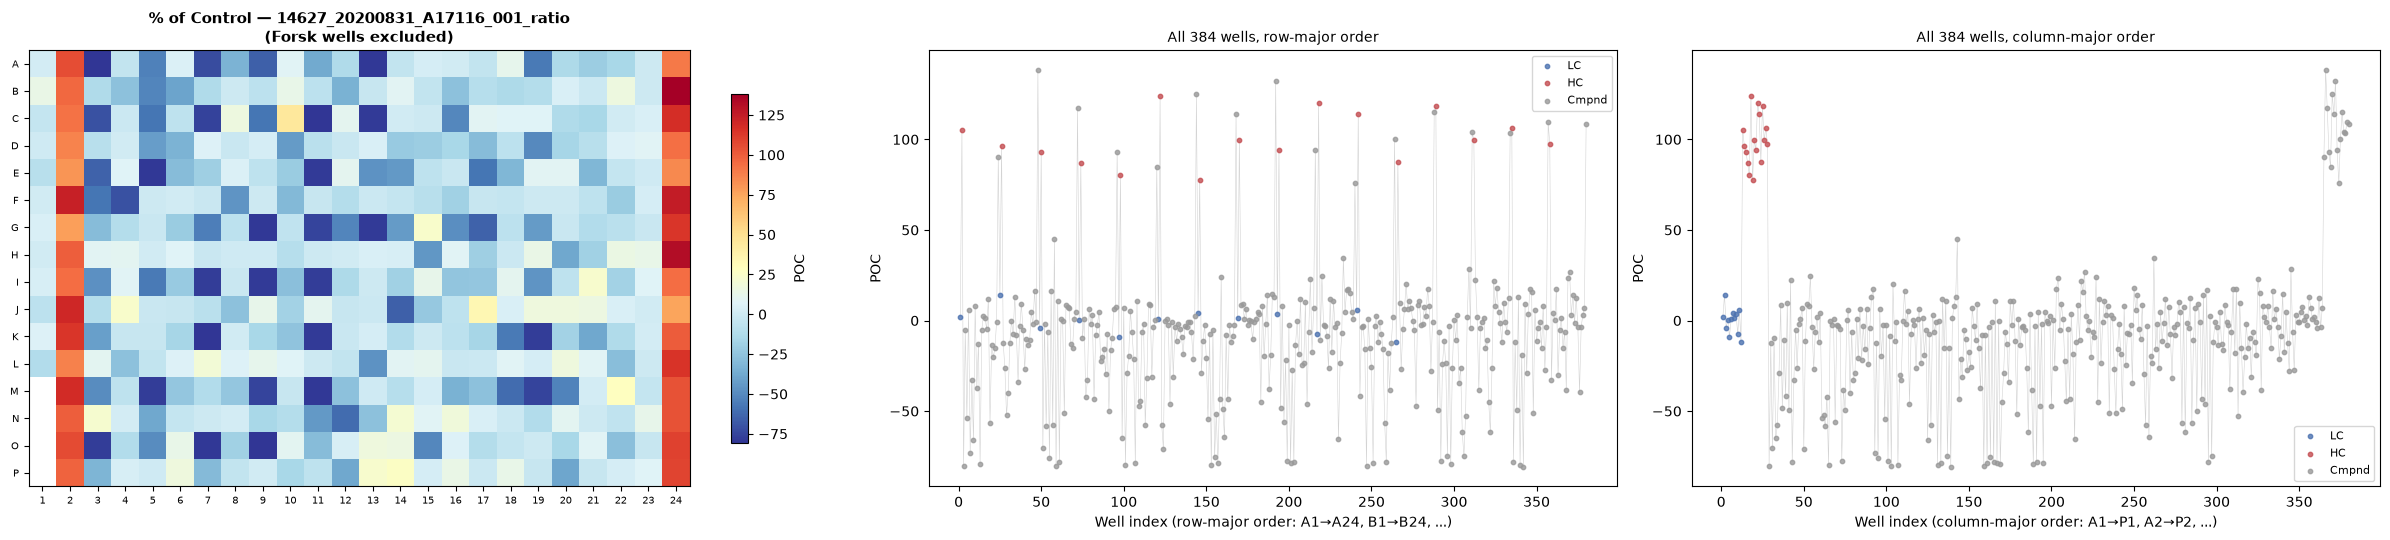

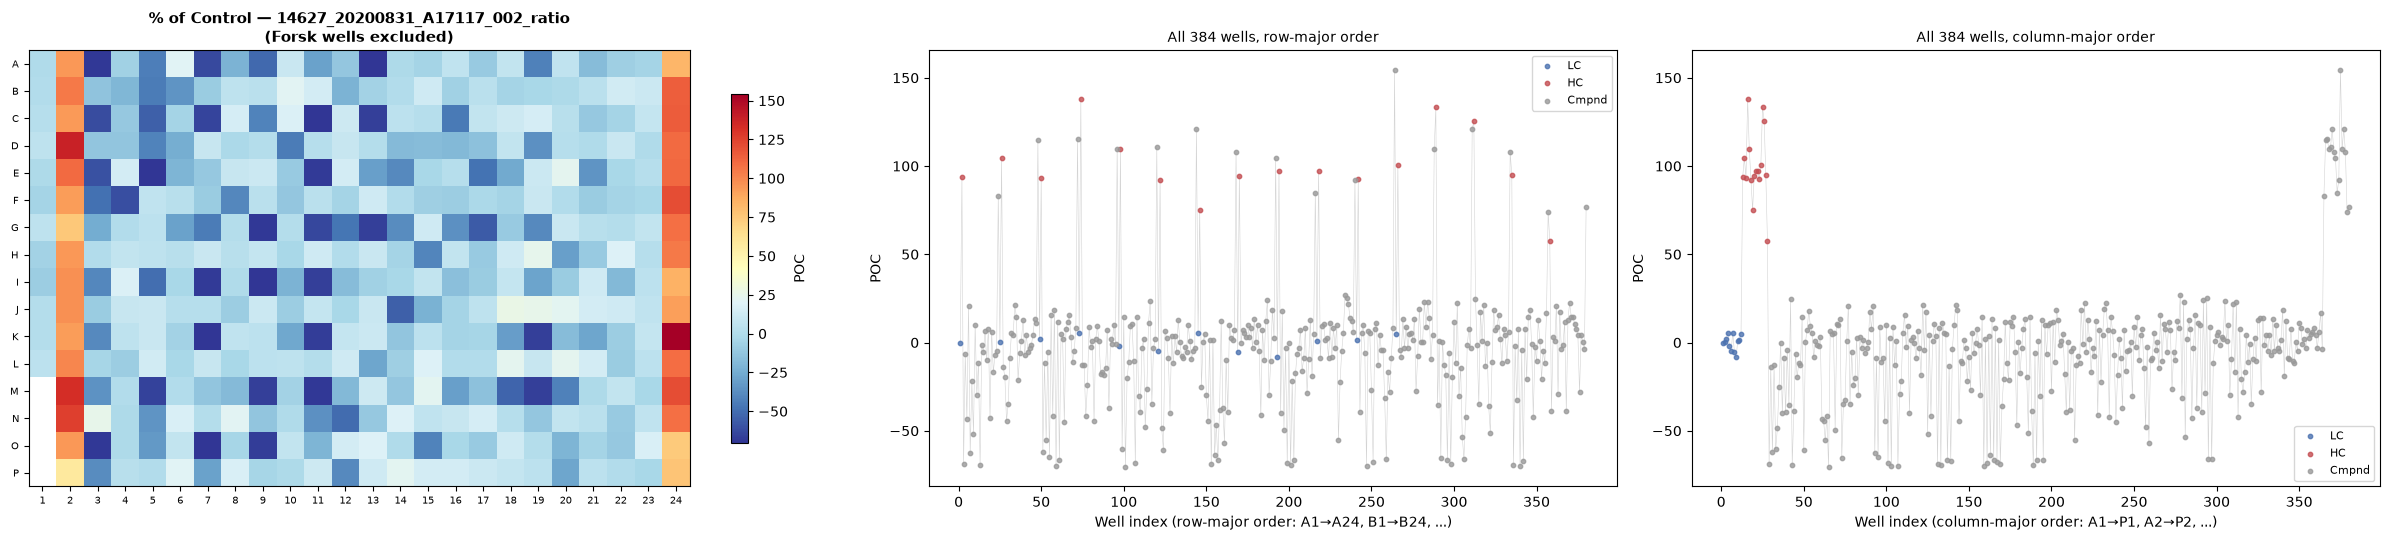

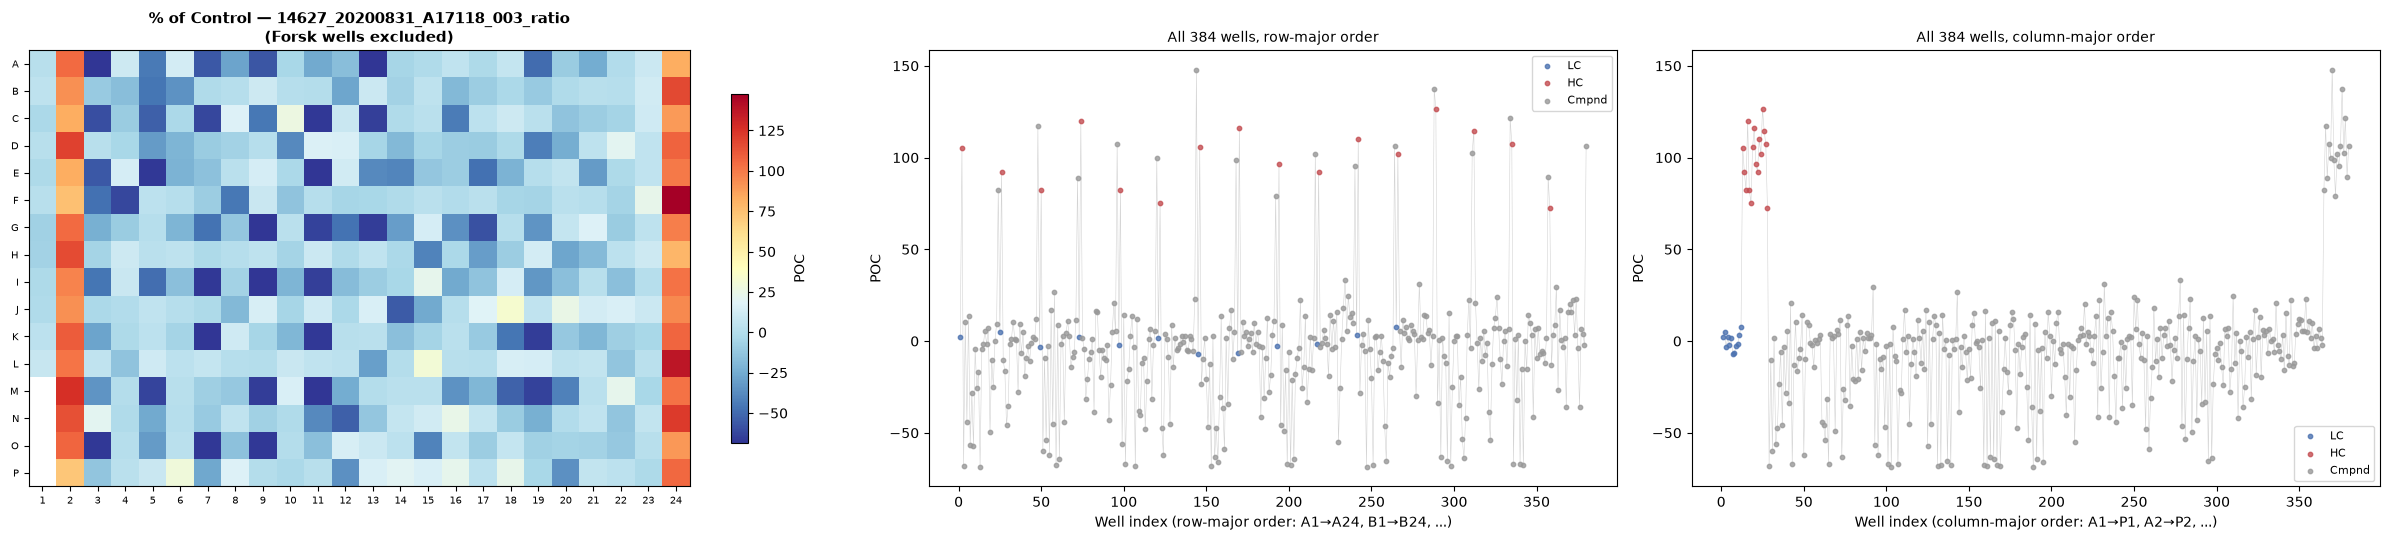

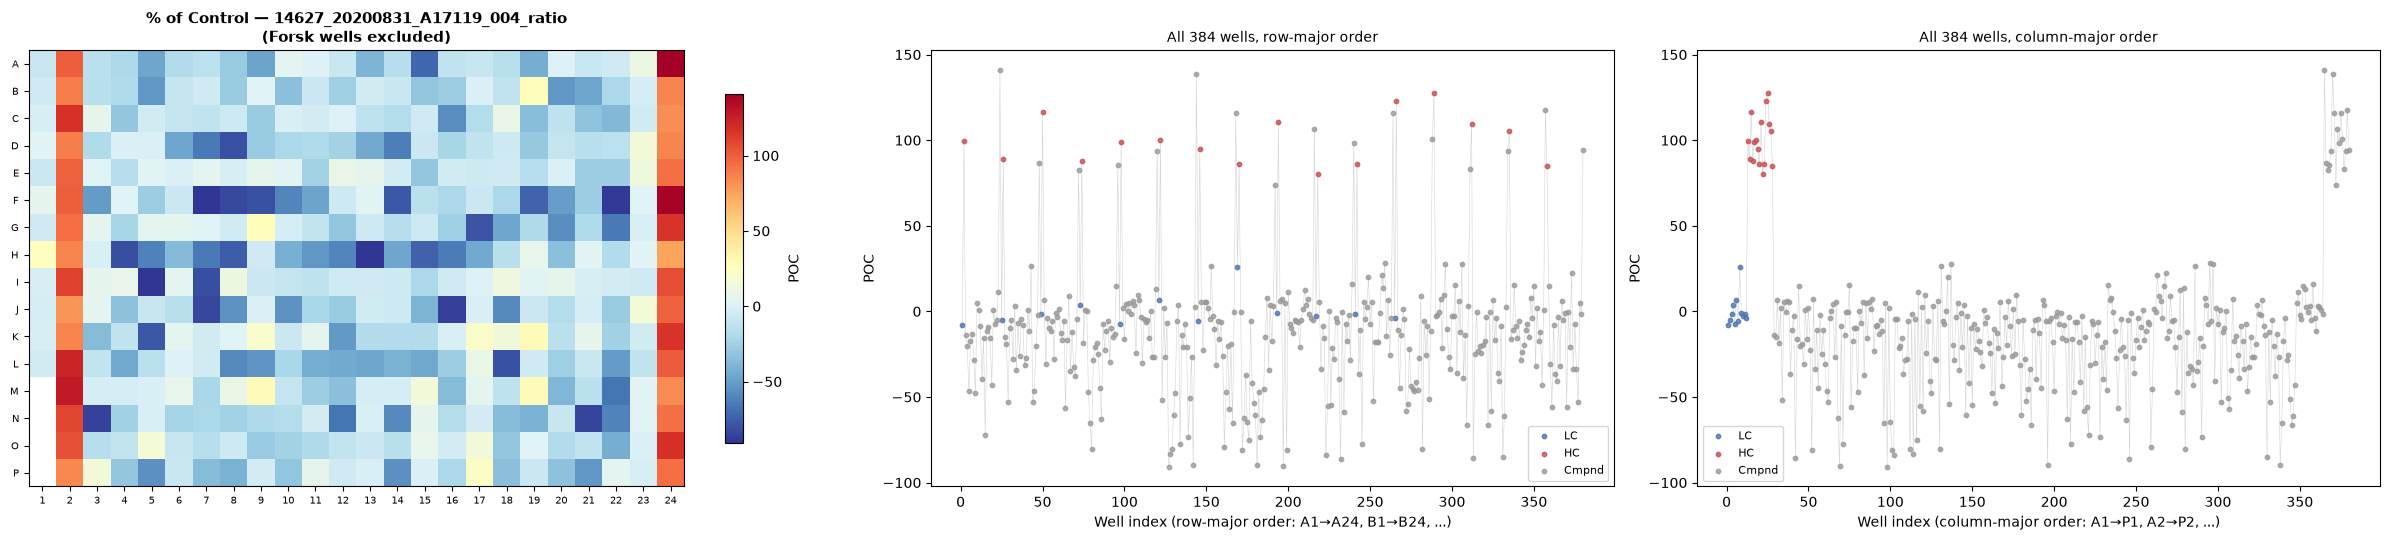

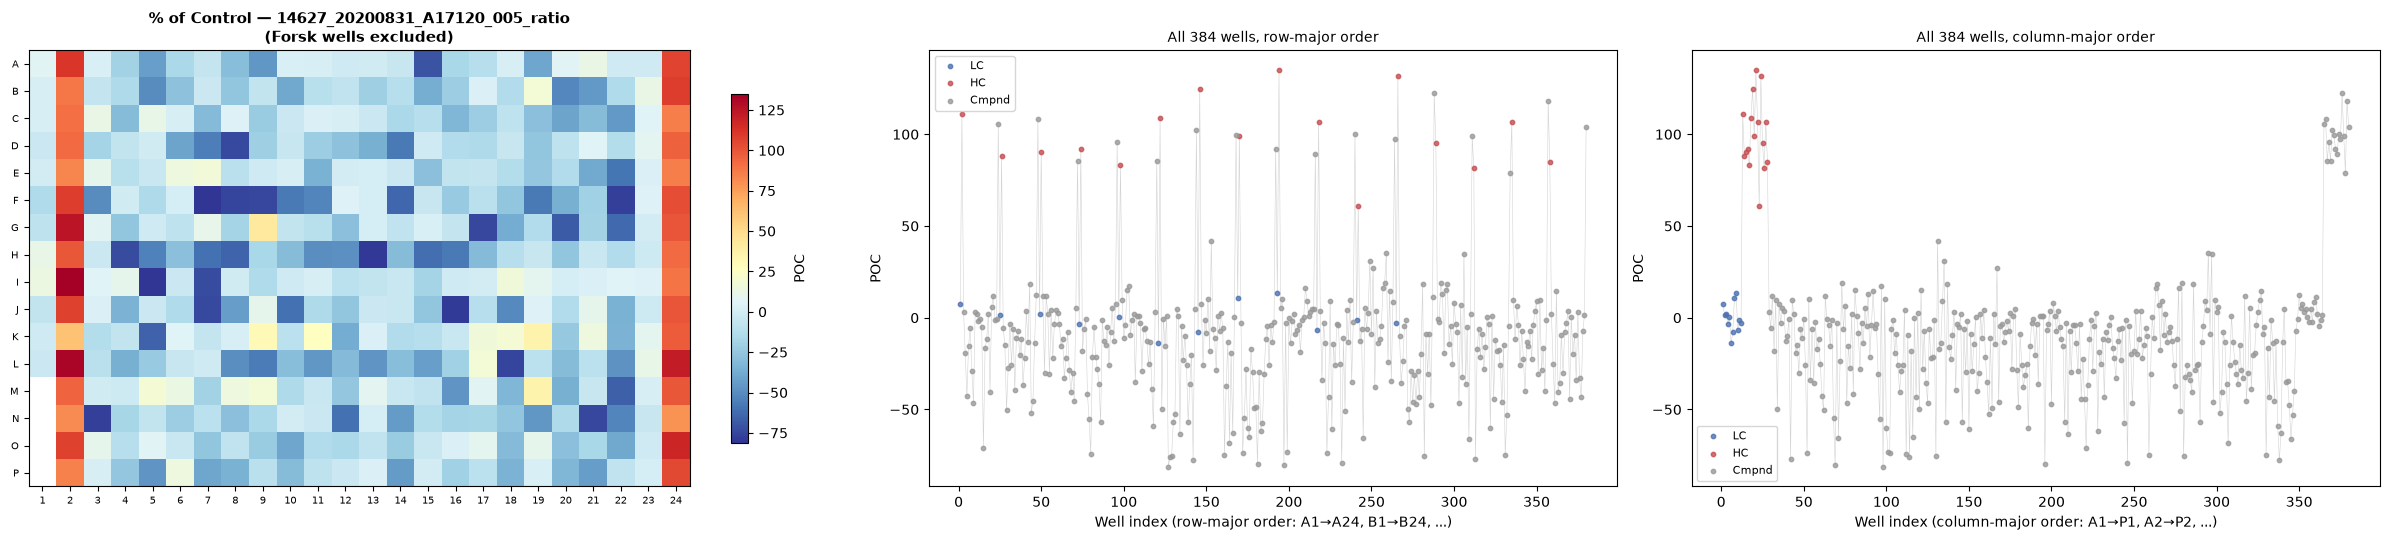

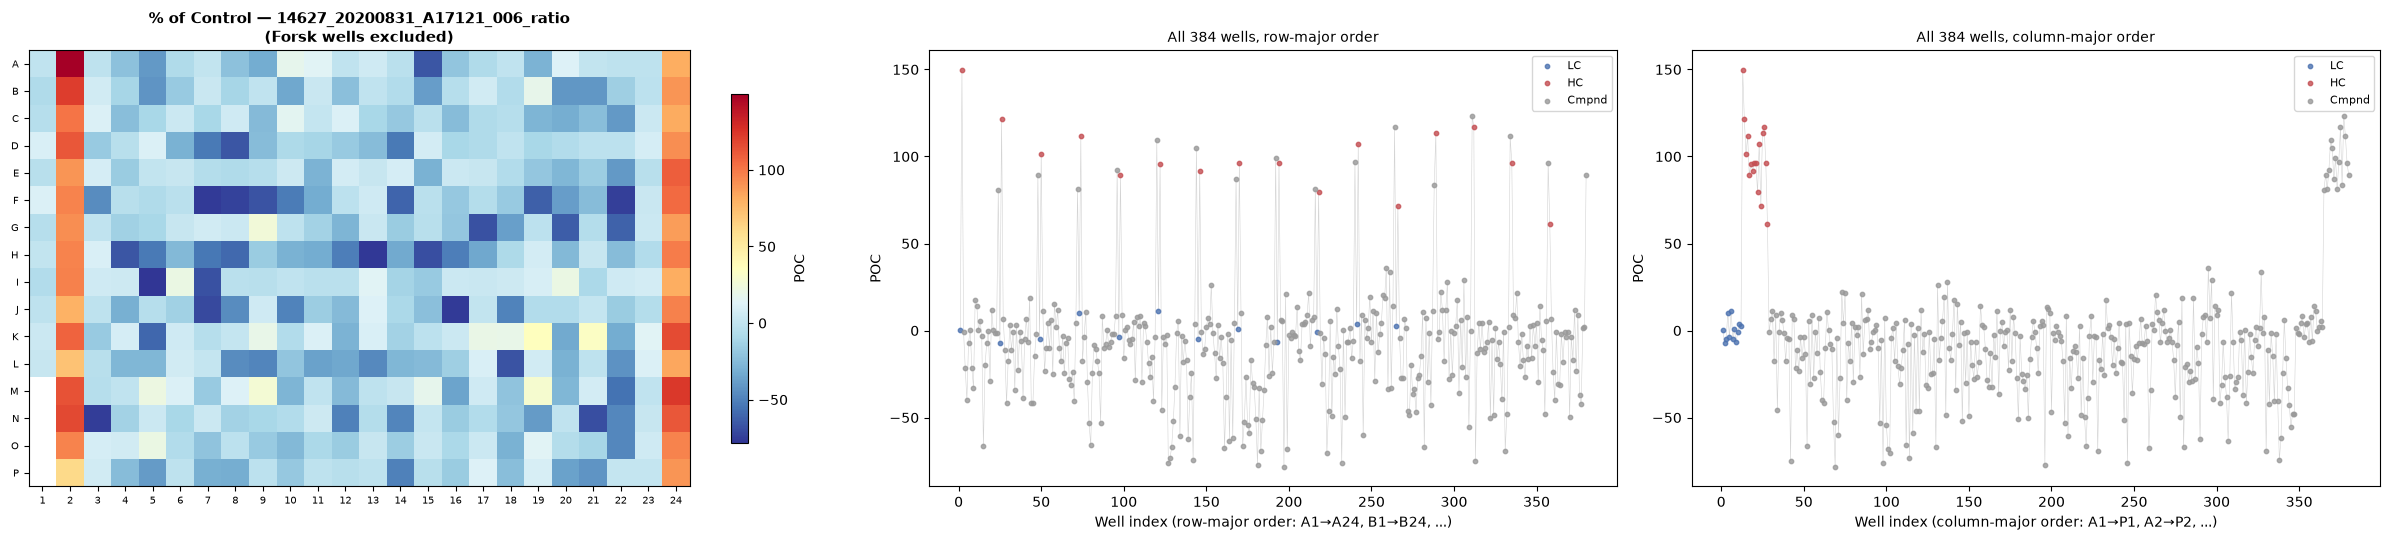

In [54]:
qc_rows = []
for plate_id, sub in raw.groupby("plate"):
    lc = sub.loc[sub["well_type"] == LOW_CTRL_LABEL, "signal"]
    hc = sub.loc[sub["well_type"] == HIGH_CTRL_LABEL, "signal"]
    z = 1 - (3 * (lc.std() + hc.std())) / abs(hc.mean() - lc.mean())
    qc_rows.append({
        "plate": plate_id,
        "LC_mean": lc.mean(), "HC_mean": hc.mean(),
        "LC_cv_pct": 100 * lc.std() / lc.mean(), "HC_cv_pct": 100 * hc.std() / hc.mean(),
        "z_factor": z
    })

qc_table = pd.DataFrame(qc_rows).round(3)
print(qc_table)

plates = raw["plate"].unique()
type_colors = {LOW_CTRL_LABEL: "#4C72B0", HIGH_CTRL_LABEL: "#C44E52", SAMPLE_LABEL: "#999999"}

for plate_id in plates:
    sub = raw[raw["plate"] == plate_id].copy()
    sub_no_forsk = sub[sub["well_type"] != FORSK_LABEL].copy()

    sub_no_forsk["row_idx"] = sub_no_forsk["well"].str[0].apply(lambda l: ord(l) - ord('A'))
    sub_no_forsk["col_idx"] = sub_no_forsk["well"].str[1:].astype(int) - 1

    fig, axes = plt.subplots(1, 3, figsize=(24, 5.5), gridspec_kw={"width_ratios": [1.2, 1, 1]})

    # --- Heatmap (Forsk wells left blank) ---
    grid = np.full((N_ROWS, N_COLS), np.nan)
    for _, r in sub_no_forsk.iterrows():
        grid[r["row_idx"], r["col_idx"]] = r["POC"]

    ax = axes[0]
    im = ax.imshow(grid, cmap="RdYlBu_r", aspect="auto")
    ax.set_xticks(range(N_COLS)); ax.set_xticklabels(range(1, N_COLS + 1), fontsize=7)
    ax.set_yticks(range(N_ROWS)); ax.set_yticklabels([chr(ord('A') + i) for i in range(N_ROWS)], fontsize=7)
    ax.set_title(f"% of Control — {plate_id}\n(Forsk wells excluded)", fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.8, label="POC")

    # --- All wells, row-major order (A1..A24, B1..B24, ... P1..P24) -> x = 1..384 ---
    row_major = sub_no_forsk.sort_values(["row_idx", "col_idx"]).reset_index(drop=True)
    row_major["plate_index"] = row_major.index + 1

    ax = axes[1]
    for wtype, color in type_colors.items():
        wsub = row_major[row_major["well_type"] == wtype]
        ax.scatter(wsub["plate_index"], wsub["POC"], s=10, color=color, label=wtype, alpha=0.8)
    ax.plot(row_major["plate_index"], row_major["POC"], "-", linewidth=0.4, color="lightgray", zorder=0)
    ax.set_xlabel("Well index (row-major order: A1→A24, B1→B24, ...)")
    ax.set_ylabel("POC")
    ax.set_title("All 384 wells, row-major order", fontsize=10)
    ax.legend(fontsize=8)

    # --- All wells, column-major order (A1..P1, A2..P2, ... A24..P24) -> x = 1..384 ---
    col_major = sub_no_forsk.sort_values(["col_idx", "row_idx"]).reset_index(drop=True)
    col_major["plate_index"] = col_major.index + 1

    ax = axes[2]
    for wtype, color in type_colors.items():
        wsub = col_major[col_major["well_type"] == wtype]
        ax.scatter(wsub["plate_index"], wsub["POC"], s=10, color=color, label=wtype, alpha=0.8)
    ax.plot(col_major["plate_index"], col_major["POC"], "-", linewidth=0.4, color="lightgray", zorder=0)
    ax.set_xlabel("Well index (column-major order: A1→P1, A2→P2, ...)")
    ax.set_ylabel("POC")
    ax.set_title("All 384 wells, column-major order", fontsize=10)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

In [57]:
DATA_DIR = r"C:\Users\sbrown\Documents\2026\08282020_GPR52_glosensor_S1P1_CYM_Lib\Data\ratios"

RUN_LIST_PATH = os.path.join(DATA_DIR, "Run_List.txt")
COMPOUND_MAP_PATH = os.path.join(DATA_DIR, "compound_plate_mapping.csv")
OUTPUT_PATH = os.path.join(DATA_DIR, "assayfile_compound_mapping.csv")

# Sanity check before running anything else
for label, p in [("Run_List.txt", RUN_LIST_PATH), ("compound_plate_mapping.csv", COMPOUND_MAP_PATH)]:
    if not os.path.exists(p):
        print(f"⚠ Missing: {label} -> {p}")
    else:
        print(f"✓ Found: {label}")

✓ Found: Run_List.txt
✓ Found: compound_plate_mapping.csv


In [58]:
import pandas as pd
import os

# ---------------- CONFIG ----------------
DATA_DIR = r"C:\Users\sbrown\Documents\2026\08282020_GPR52_glosensor_S1P1_CYM_Lib\Data\ratios"

RUN_LIST_PATH = os.path.join(DATA_DIR, "Run_List.txt")
COMPOUND_MAP_PATH = os.path.join(DATA_DIR, "compound_plate_mapping.csv")
OUTPUT_PATH = os.path.join(DATA_DIR, "assayfile_compound_mapping.csv")
# -----------------------------------------

run_list = pd.read_csv(RUN_LIST_PATH, sep="\t")
run_list.columns = [c.strip() for c in run_list.columns]          # clean up header whitespace
run_list["CompoundPlates"] = run_list["CompoundPlates"].str.strip()
run_list["AssayFiles"] = run_list["AssayFiles"].str.strip()        # source file has leading spaces before filenames

compound_map = pd.read_csv(COMPOUND_MAP_PATH, dtype=str)

# Each destination plate_number was pooled from TWO source compound-plate codes
# (plate_name_1 and plate_name_2), so a CompoundPlates code can match either column.
code_to_plate = {}
for _, r in compound_map[["plate_number", "plate_name_1", "plate_name_2"]].drop_duplicates().iterrows():
    code_to_plate[r["plate_name_1"]] = r["plate_number"]
    code_to_plate[r["plate_name_2"]] = r["plate_number"]

run_list["plate_number"] = run_list["CompoundPlates"].map(code_to_plate)

unmatched = run_list.loc[run_list["plate_number"].isna(), "CompoundPlates"].unique()
if len(unmatched):
    print(f"⚠ CompoundPlates code(s) not found in compound_plate_mapping.csv: {list(unmatched)}")

# Expand: every assay file gets the full 384-well barcode/compound_id table for its plate
assayfile_map = run_list.merge(compound_map, on="plate_number", how="left")

print(f"{run_list['AssayFiles'].nunique()} assay file(s) mapped to {assayfile_map['plate_number'].nunique()} plate(s)")
print(f"Total rows: {len(assayfile_map)}  (should be n_assay_files x 384)")

assayfile_map.to_csv(OUTPUT_PATH, index=False)
print(f"Saved to {OUTPUT_PATH}")

assayfile_map.head(10)

6 assay file(s) mapped to 2 plate(s)
Total rows: 2304  (should be n_assay_files x 384)
Saved to C:\Users\sbrown\Documents\2026\08282020_GPR52_glosensor_S1P1_CYM_Lib\Data\ratios\assayfile_compound_mapping.csv


,CompoundPlates,AssayFiles,plate_number,plate_name_1,plate_name_2,well,barcode,compound_id
0,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,A01,No Tube,NaN
1,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,B01,No Tube,NaN
2,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,C01,No Tube,NaN
3,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,D01,No Tube,NaN
4,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,E01,No Tube,NaN
5,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,F01,No Tube,NaN
6,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,G01,No Tube,NaN
7,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,H01,No Tube,NaN
8,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,I01,No Tube,NaN
9,C10539,14627_20200831_A17116_001_ratio.csv,01,C10539,C10540,J01,No Tube,NaN
